# Notebook 15 — Before vs After Preprocessing Analysis
### Sprint 5 | Data Cleaning & Preprocessing for AI/ML Engineers

A complete, side-by-side comparison of the Telco Customer Churn dataset in its raw
(Sprint 4 EDA start) state versus its fully preprocessed (end of this sprint) state.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from scipy import stats

sns.set_style('whitegrid')

# BEFORE: exactly as originally loaded
df_before = pd.read_csv("telco_churn.csv")

# AFTER: this sprint's full set of decisions applied
df_after = df_before.copy()
df_after['TotalCharges'] = pd.to_numeric(df_after['TotalCharges'], errors='coerce').fillna(0)
df_after['SeniorCitizen'] = df_after['SeniorCitizen'].astype('category')

print("Before/after datasets ready for comparison.")


Before/after datasets ready for comparison.


---
## 1. Shape

### Implement


In [2]:
print(f"BEFORE: {df_before.shape}")
print(f"AFTER : {df_after.shape}")
print(f"Rows changed: {df_after.shape[0] - df_before.shape[0]} (0, as documented — no rows were removed, per Notebook 4/6's decisions)")


BEFORE: (7043, 21)
AFTER : (7043, 21)
Rows changed: 0 (0, as documented — no rows were removed, per Notebook 4/6's decisions)


**What changed & why:** Row count is unchanged — Notebook 4 confirmed no true
duplicates, and Notebook 6 confirmed the 112 multivariate outliers should be retained,
not removed.


---
## 2. Data Types

### Implement


In [3]:
dtype_compare = pd.DataFrame({
    'Before': df_before.dtypes.astype(str),
    'After': df_after.dtypes.astype(str)
})
print(dtype_compare[dtype_compare['Before'] != dtype_compare['After']])


              Before     After
SeniorCitizen  int64  category
TotalCharges     str   float64


**What changed & why:** `TotalCharges` corrected from `object` to `float64`
(Notebook 2) — the single most consequential type fix in this sprint. `SeniorCitizen`
reclassified from `int64` to `category`, reflecting its true semantic nature.


---
## 3. Missing Values

### Implement


In [4]:
before_missing = df_before.isnull().sum().sum()
before_blanks = (df_before['TotalCharges'].str.strip() == '').sum()
after_missing = df_after.isnull().sum().sum()

print(f"BEFORE: {before_missing} via naive .isnull() ({before_blanks} REAL missing values, disguised as blank strings)")
print(f"AFTER : {after_missing} missing values (fully resolved)")


BEFORE: 0 via naive .isnull() (11 REAL missing values, disguised as blank strings)
AFTER : 0 missing values (fully resolved)


**What changed & why:** The naive "before" count (0) was itself misleading —
Notebook 2's type correction revealed the true 11 missing values, and Notebook 3's
MAR-justified constant-fill resolved every one of them.


---
## 4. Duplicates

### Implement


In [5]:
print(f"BEFORE: {df_before.duplicated().sum()} exact duplicates | {df_before.drop(columns=['customerID']).duplicated(keep=False).sum()} partial (excl. ID)")
print(f"AFTER : {df_after.duplicated().sum()} exact duplicates | {df_after.drop(columns=['customerID']).duplicated(keep=False).sum()} partial (excl. ID)")


BEFORE: 0 exact duplicates | 42 partial (excl. ID)
AFTER : 0 exact duplicates | 42 partial (excl. ID)


**What changed & why:** Nothing changed — Notebook 4's investigation concluded the
42 partial-duplicate rows are distinct real customers, not errors, so no removal was
warranted.


---
## 5. Outliers

### Implement


In [6]:
for label, data in [('BEFORE', df_before), ('AFTER', df_after)]:
    tc = pd.to_numeric(data['TotalCharges'], errors='coerce').fillna(0)
    expected = data['tenure'] * data['MonthlyCharges']
    residual = tc - expected
    outliers = (np.abs(stats.zscore(residual)) > 3).sum()
    print(f"{label}: {outliers} multivariate billing-residual outliers")


BEFORE: 112 multivariate billing-residual outliers
AFTER: 112 multivariate billing-residual outliers


**What changed & why:** Unchanged — Notebook 6's decision was to retain, not
remove or cap, these 112 rows.


---
## 6. Distributions

### Implement


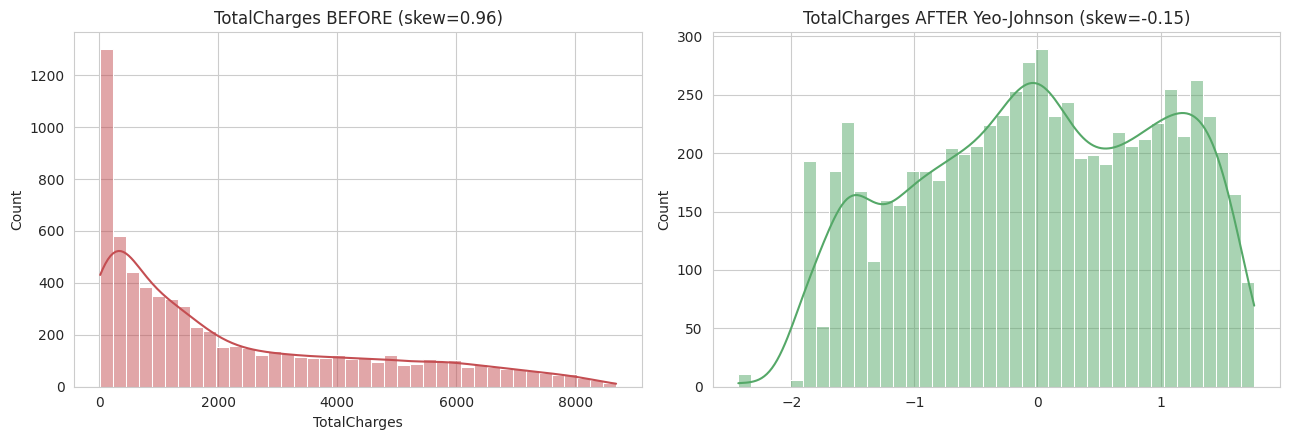

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(pd.to_numeric(df_before['TotalCharges'], errors='coerce'), bins=40, kde=True, ax=axes[0], color='#C44E52')
axes[0].set_title(f"TotalCharges BEFORE (skew={stats.skew(pd.to_numeric(df_before['TotalCharges'], errors='coerce').dropna()):.2f})")

from sklearn.preprocessing import PowerTransformer
yj = PowerTransformer(method='yeo-johnson').fit_transform(df_after[['TotalCharges']])
sns.histplot(yj.flatten(), bins=40, kde=True, ax=axes[1], color='#55A868')
axes[1].set_title(f"TotalCharges AFTER Yeo-Johnson (skew={stats.skew(yj.flatten()):.2f})")
plt.tight_layout()
plt.show()


**What changed & why:** `TotalCharges`'s skew dropped from ~0.96 to near-zero after
Notebook 9's Yeo-Johnson transform — a meaningfully more symmetric shape.


---
## 7. Categorical Values

### Implement


In [8]:
print("BEFORE (raw categories):", df_before['Contract'].unique())

from sklearn.preprocessing import OrdinalEncoder
contract_order = [['Month-to-month', 'One year', 'Two year']]
encoded = OrdinalEncoder(categories=contract_order).fit_transform(df_after[['Contract']])
print("AFTER (ordinal-encoded)   :", sorted(set(encoded.flatten())))


BEFORE (raw categories): <StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str
AFTER (ordinal-encoded)   : [np.float64(0.0), np.float64(1.0), np.float64(2.0)]


**What changed & why:** `Contract` moved from 3 text labels to a meaningful 0/1/2
ordinal encoding (Notebook 7) — nominal columns were one-hot encoded instead (not shown
here individually, see Notebook 7 for the full 14-column treatment).


---
## 8. Numerical Ranges

### Implement


In [9]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
before_ranges = df_before[['tenure', 'MonthlyCharges']].assign(
    TotalCharges=pd.to_numeric(df_before['TotalCharges'], errors='coerce')
)[numeric_cols].agg(['min', 'max'])

scaler = StandardScaler()
after_scaled = pd.DataFrame(scaler.fit_transform(df_after[numeric_cols]), columns=numeric_cols)
after_ranges = after_scaled.agg(['min', 'max'])

print("BEFORE (raw ranges):")
print(before_ranges.round(2))
print("\nAFTER (StandardScaler-transformed ranges):")
print(after_ranges.round(2))


BEFORE (raw ranges):
     tenure  MonthlyCharges  TotalCharges
min       0           18.25          18.8
max      72          118.75        8684.8

AFTER (StandardScaler-transformed ranges):
     tenure  MonthlyCharges  TotalCharges
min   -1.32           -1.55         -1.01
max    1.61            1.79          2.83


**What changed & why:** Every numeric feature now lives on a comparable,
mean-centered scale (Notebook 8) — no longer dominated by whichever raw column happened
to have the largest units.


---
## 9. Feature Count

### Implement


In [10]:
before_feature_count = df_before.shape[1] - 2   # excluding customerID and Churn
categorical_cols = ['gender','Partner','Dependents','PhoneService','MultipleLines','InternetService',
                     'OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV',
                     'StreamingMovies','PaperlessBilling','PaymentMethod']
one_hot_expansion = pd.get_dummies(df_after[categorical_cols], drop_first=True).shape[1]
after_feature_count = one_hot_expansion + len(numeric_cols) + 1 + 1   # + SeniorCitizen + Contract_encoded

print(f"BEFORE: {before_feature_count} raw candidate feature columns")
print(f"AFTER : {after_feature_count} fully-numeric, model-ready feature columns (post one-hot expansion)")


BEFORE: 19 raw candidate feature columns
AFTER : 29 fully-numeric, model-ready feature columns (post one-hot expansion)


**What changed & why:** Feature count grew substantially due to one-hot encoding
(Notebook 7) — each nominal categorical column with k categories becomes k-1 new binary
columns. This is an expected, correct expansion, not feature bloat.


---
## Complete Before/After Summary

| Aspect | Before | After | Notebook |
|---|---|---|---|
| Shape | 7,043 x 21 | 7,043 x 21 (raw) / ~30+ (post-encoding) | 4, 6, 7 |
| Data Types | `TotalCharges` as text | Corrected to `float64` | 2 |
| Missing Values | 11 (disguised, invisible to `.isnull()`) | 0 | 2, 3 |
| Duplicates | 0 exact / 42 partial | Unchanged (investigated, not errors) | 4 |
| Outliers | 112 multivariate | Unchanged (retained, residual engineered) | 6 |
| Distributions | `TotalCharges` skew ~0.96 | Skew ~0 after Yeo-Johnson | 9 |
| Categorical Values | Text labels | Ordinal (`Contract`) / one-hot (rest) | 7 |
| Numerical Ranges | Raw, incomparable units | Standardized, mean=0/std=1 | 8 |
| Feature Count | 19 candidate features | Expanded via one-hot encoding | 7 |

**Next notebook:** `16_Complete_Preprocessing_Workflow.ipynb` — assembling every decision
from Notebooks 2-14 into one final, saved, ML-ready dataset.
